In [2]:
# import libraries
import time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from arch import arch_model

In [3]:
# ==============================================================================
# Environment Setup
# ==============================================================================
# %pip install arch
# Why use %pip instead of !pip or the terminal?
# The %pip magic directive ensures that the installation happens strictly 
# within the exact environment/executable where the Notebook Kernel is 
# currently running, eliminating any path errors.

In [28]:
# ==============================================================================
# 1. Data Collection and Preparation
# ==============================================================================
def fetch_clean_series(ticker: str, start_date: str = "2021-01-01", max_retries: int = 3) -> pd.Series:
    """
    Fetches historical closing prices for a given ticker with a retry mechanism.

    Args:
        ticker (str): The financial asset's ticker symbol.
        start_date (str, optional): The start date for the data download (YYYY-MM-DD). Defaults to "2021-01-01".
        max_retries (int, optional): Maximum number of attempts if the download fails. Defaults to 3.

    Returns:
        pd.Series: A pandas Series containing the cleaned closing prices without missing values.

    Raises:
        RuntimeError: If the data cannot be downloaded after the maximum number of retries.
    """
    for attempt in range(max_retries):
        try:
            data = yf.download(ticker, start=start_date, progress=False, auto_adjust=False)
            if not data.empty:
                if isinstance(data.columns, pd.MultiIndex):
                    series = data["Close"][ticker]
                else:
                    series = data["Close"]
                return series.dropna()
        except Exception as e:
            print(f"[{ticker}] Error on attempt {attempt + 1}: {e}")
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Failed to download {ticker}.")

def prepare_returns_pair(ticker_a: str, ticker_b: str, label_a: str, label_b: str, start_date: str = "2021-01-01"):
    """
    Downloads and synchronizes time series for a pair of assets, calculating logarithmic returns.

    Args:
        ticker_a (str): Ticker symbol for the first asset.
        ticker_b (str): Ticker symbol for the second asset.
        label_a (str): Descriptive label for the first asset.
        label_b (str): Descriptive label for the second asset.
        start_date (str, optional): The start date for the data download. Defaults to "2021-01-01".

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: Synchronized daily prices for both assets.
            - pd.DataFrame: Synchronized daily logarithmic returns (multiplied by 100).
    """
    s_a = fetch_clean_series(ticker_a, start_date)
    time.sleep(1.5)
    s_b = fetch_clean_series(ticker_b, start_date)
    
    df_prices = pd.DataFrame({label_a: s_a, label_b: s_b}).dropna()
    
    # Logarithmic returns multiplied by 100 for GARCH numerical stability
    returns = (np.log(df_prices / df_prices.shift(1)).dropna()) * 100
    
    # FILTER: Remove days where returns are exactly zero (mismatched holidays)
    valid_trading_days = (returns[label_a] != 0.0) & (returns[label_b] != 0.0)
    returns = returns.loc[valid_trading_days]
    
    # Align prices dataframe to match the filtered returns index
    df_prices = df_prices.loc[returns.index]
    
    return df_prices, returns

# ==============================================================================
# 2. Correlation Estimation Methods
# ==============================================================================
def compute_rolling_corr(returns: pd.DataFrame, col_a: str, col_b: str, window: int = 60) -> pd.Series:
    """
    Computes the classic Pearson correlation using a uniform rolling window.

    Args:
        returns (pd.DataFrame): DataFrame containing the asset returns.
        col_a (str): Column name for the first asset.
        col_b (str): Column name for the second asset.
        window (int, optional): Number of periods for the rolling window. Defaults to 60.

    Returns:
        pd.Series: A pandas Series representing the rolling correlation over time.
    """
    return returns[col_a].rolling(window=window).corr(returns[col_b])

def compute_ewma_corr(returns: pd.DataFrame, col_a: str, col_b: str, decay: float = 0.94) -> pd.Series:
    """
    Computes the Exponentially Weighted Moving Average (EWMA) correlation (RiskMetrics).

    Args:
        returns (pd.DataFrame): DataFrame containing the asset returns.
        col_a (str): Column name for the first asset.
        col_b (str): Column name for the second asset.
        decay (float, optional): The decay factor (lambda). Defaults to 0.94.

    Returns:
        pd.Series: A pandas Series representing the EWMA dynamic correlation.
    """
    r1 = returns[col_a]
    r2 = returns[col_b]
    
    cov_12 = r1.ewm(alpha=1 - decay).cov(r2)
    var_1 = r1.ewm(alpha=1 - decay).var()
    var_2 = r2.ewm(alpha=1 - decay).var()
    
    return cov_12 / np.sqrt(var_1 * var_2)

def fit_dcc_garch(returns: pd.DataFrame, col_a: str, col_b: str) -> pd.Series:
    """
    Estimates the Dynamic Conditional Correlation (DCC-GARCH) model.
    
    This robust version includes a constant mean correction (drift), strict 
    parameter bounds to prevent static collapse (constant straight line), 
    and a vectorized inner loop for optimization efficiency.

    Args:
        returns (pd.DataFrame): Synchronized daily logarithmic returns.
        col_a (str): Column name for the first asset in the returns dataframe.
        col_b (str): Column name for the second asset in the returns dataframe.

    Returns:
        pd.Series: A time series containing the dynamic conditional correlation 
                   between the two assets, aligned with the input returns index.
    """
    r1 = returns[col_a].values
    r2 = returns[col_b].values
    T = len(r1)

    # 1. Univariate GARCH(1,1) Fit with Constant Mean (Corrects Drift)
    am1 = arch_model(r1, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')
    res1 = am1.fit(disp='off')
    std_resid1 = res1.resid / res1.conditional_volatility

    am2 = arch_model(r2, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')
    res2 = am2.fit(disp='off')
    std_resid2 = res2.resid / res2.conditional_volatility

    eps = np.column_stack([std_resid1, std_resid2])
    Q_bar = np.cov(eps.T)

    # 2. Negative Log-Likelihood for the DCC Step
    def dcc_nll(params):
        a, b = params
        nll = 0.0
        Q = Q_bar.copy()
        
        for t in range(1, T):
            e_prev = eps[t - 1]
            # Efficient calculation of the innovation matrix via outer product
            Q = (1 - a - b) * Q_bar + a * np.outer(e_prev, e_prev) + b * Q
            
            q11 = np.maximum(Q[0, 0], 1e-6)
            q22 = np.maximum(Q[1, 1], 1e-6)
            rho = Q[0, 1] / np.sqrt(q11 * q22)
            
            # Numerical limit for correlation to avoid Log(0)
            rho = np.clip(rho, -0.999, 0.999)
            
            det_R = 1.0 - rho**2
            e1, e2 = eps[t, 0], eps[t, 1]
            
            quad_form = (e1**2 + e2**2 - 2.0 * rho * e1 * e2) / det_R
            nll += np.log(det_R) + quad_form
            
        return nll

    # a >= 0.01 prevents the model from collapsing to a straight line
    bounds = [(0.01, 0.30), (0.50, 0.98)] 
    constraints = ({'type': 'ineq', 'fun': lambda x: 0.999 - x[0] - x[1]}) # a + b < 1
    
    init_params = [0.03, 0.95]
    
    opt_res = minimize(
        dcc_nll, 
        init_params, 
        bounds=bounds, 
        constraints=constraints,
        method='SLSQP', 
        options={'ftol': 1e-6, 'disp': False}
    )
    
    a_opt, b_opt = opt_res.x

    # Reconstruction of the dynamic correlation series
    dcc_corr = np.zeros(T)
    dcc_corr[0] = Q_bar[0, 1] / np.sqrt(Q_bar[0, 0] * Q_bar[1, 1])
    Q = Q_bar.copy()
    
    for t in range(1, T):
        e_prev = eps[t - 1]
        Q = (1 - a_opt - b_opt) * Q_bar + a_opt * np.outer(e_prev, e_prev) + b_opt * Q
        
        q11 = np.maximum(Q[0, 0], 1e-6)
        q22 = np.maximum(Q[1, 1], 1e-6)
        rho = Q[0, 1] / np.sqrt(q11 * q22)
        dcc_corr[t] = np.clip(rho, -0.999, 0.999)

    return pd.Series(dcc_corr, index=returns.index)

# ==============================================================================
# 3. Comparative Visualization
# ==============================================================================
def plot_models_comparison(
    prices: pd.DataFrame, 
    returns: pd.DataFrame, 
    label_a: str, 
    label_b: str,
    models_shown: list = ["Rolling", "EWMA", "DCC-GARCH"], 
    output_filename: str = "garch_comparison.png"
):
    """
    Generates and saves a two-panel comparative plot showing normalized prices 
    and the different dynamic correlation models conditionally.

    Args:
        prices (pd.DataFrame): Synchronized prices dataframe.
        returns (pd.DataFrame): Synchronized returns dataframe.
        label_a (str): Descriptive label for the first asset.
        label_b (str): Descriptive label for the second asset.
        models_shown (list, optional): List of models to display. Defaults to ["Rolling", "EWMA", "DCC-GARCH"].
        output_filename (str, optional): File path for saving the plot. Defaults to "garch_comparison.png".
    """
    print(f"Generating dashboard for {label_a} vs {label_b} using models: {', '.join(models_shown)}...")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # Panel 1: Normalized Prices
    norm_a = (prices[label_a] / prices[label_a].iloc[0]) * 100
    norm_b = (prices[label_b] / prices[label_b].iloc[0]) * 100
    ax1.plot(prices.index, norm_a, label=f"{label_a} (Base 100)", color="#1f77b4", lw=1.5)
    ax1.plot(prices.index, norm_b, label=f"{label_b} (Base 100)", color="#2ca02c", lw=1.5)
    ax1.set_title(f"Normalized Price Dynamics: {label_a} vs. {label_b}", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Normalized Index (Base 100)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Panel 2: Correlation Models Comparison (Conditional Execution)
    if "Rolling" in models_shown:
        rolling_60 = compute_rolling_corr(returns, label_a, label_b, window=60)
        ax2.plot(returns.index, rolling_60, label="Rolling Window (60d)", color="#ff7f0e", lw=1.4, linestyle="--")

    if "EWMA" in models_shown:
        ewma_corr = compute_ewma_corr(returns, label_a, label_b, decay=0.94)
        ax2.plot(returns.index, ewma_corr, label="EWMA (λ = 0.94)", color="#9467bd", lw=1.2, alpha=0.8)

    if "DCC-GARCH" in models_shown:
        dcc_corr = fit_dcc_garch(returns, label_a, label_b)
        ax2.plot(returns.index, dcc_corr, label="DCC-GARCH (1,1)", color="#d62728", lw=1.6)
    
    # Dynamic styling and titling based on selected models
    ax2.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax2.set_ylabel("Dynamic Correlation")
    
    dynamic_title = " vs. ".join(models_shown)
    ax2.set_title(f"Methodological Comparison: {dynamic_title}", fontsize=11, fontweight="bold")
    
    ax2.legend(loc="lower left")
    ax2.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    print(f"Comparative plot successfully saved: {output_filename}")
    plt.show()


\nProcessing: Exchange rate and Soybean production sensitivity
Generating dashboard for Dollar_BRL vs Soybean_CBOT using models: Rolling, DCC-GARCH...
Comparative plot successfully saved: 02_usdbrl_vs_soybean_garch.png


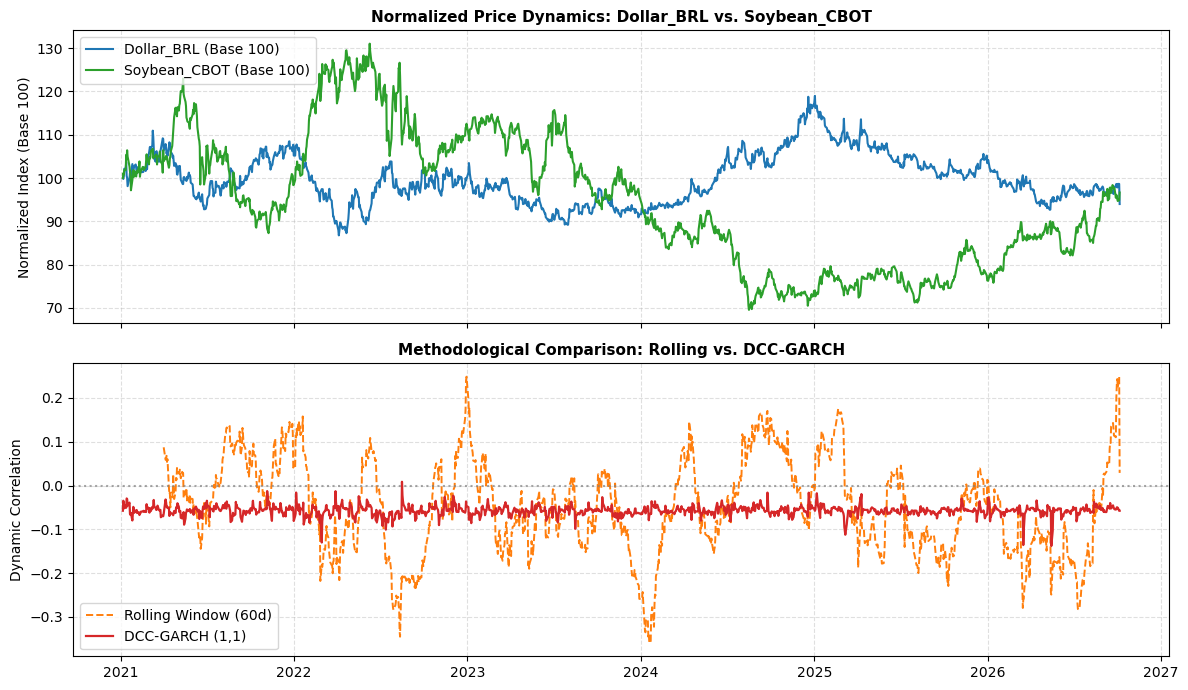

In [27]:
# ==============================================================================
# Parameterized Executions: Multi-Asset Analysis
# ==============================================================================
if __name__ == "__main__":
    
    study_pairs = [

        
        # --- Block 2: Country Risk and Agricultural Demand (Macro vs. Agro) ---
        {
            "ticker_a": "USDBRL=X", "label_a": "Dollar_BRL",
            "ticker_b": "ZS=F",     "label_b": "Soybean_CBOT",
            "output": "02_usdbrl_vs_soybean_garch.png",
            "desc": "Exchange rate and Soybean production sensitivity"
        },


    ]
    
    # Example execution loop (uncomment to run)
    for pair in study_pairs:
        print(f"\\nProcessing: {pair['desc']}")
        prices_df, returns_df = prepare_returns_pair(
            ticker_a=pair["ticker_a"], 
            ticker_b=pair["ticker_b"], 
            label_a=pair["label_a"], 
            label_b=pair["label_b"]
        )
        plot_models_comparison(
            prices=prices_df, 
            returns=returns_df, 
            label_a=pair["label_a"], 
            label_b=pair["label_b"], 
            models_shown=pair.get("models", ["Rolling", "DCC-GARCH"]),
            output_filename=pair["output"]
         )

\nProcessing: International parity pass-through vs. corporate/state risk
Generating dashboard for Petrobras_PN vs Brent_Oil using models: Rolling, EWMA, DCC-GARCH...


c:\ProgramData\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Comparative plot successfully saved: 01_petr4_vs_brent_garch.png


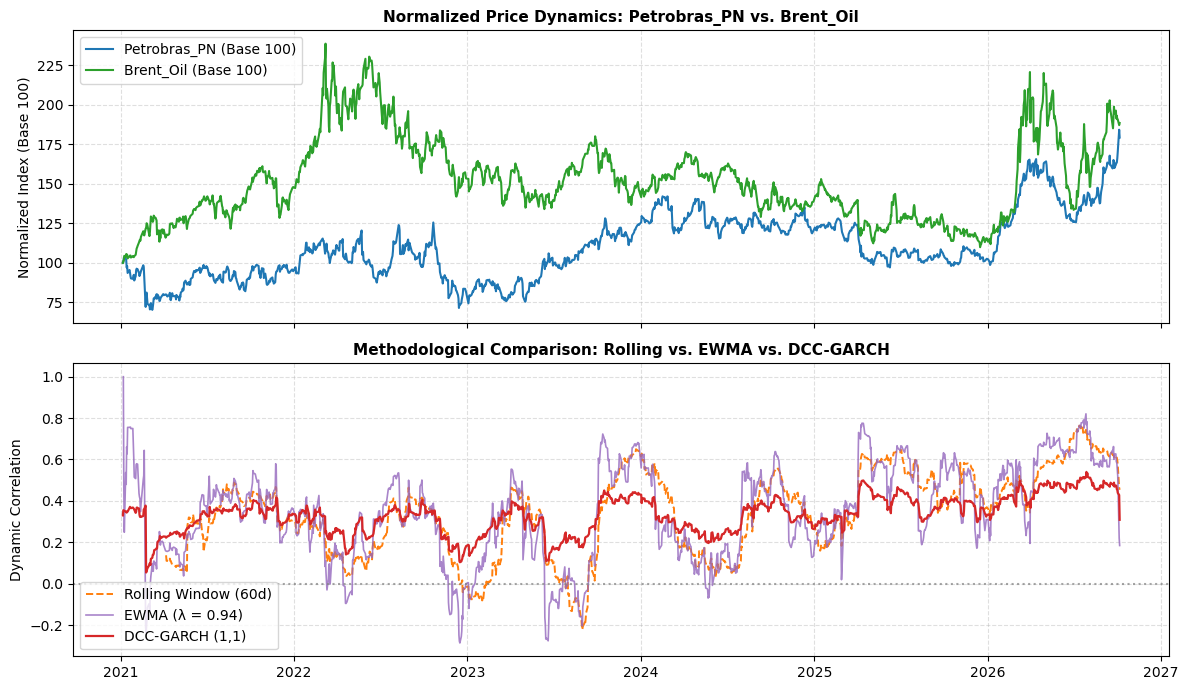

\nProcessing: Stock market sensitivity and foreign flow to harvest yields
Generating dashboard for BR_Market_EWZ vs Soybean_CBOT using models: Rolling, EWMA, DCC-GARCH...
Comparative plot successfully saved: 02_ewz_vs_soybean_garch.png


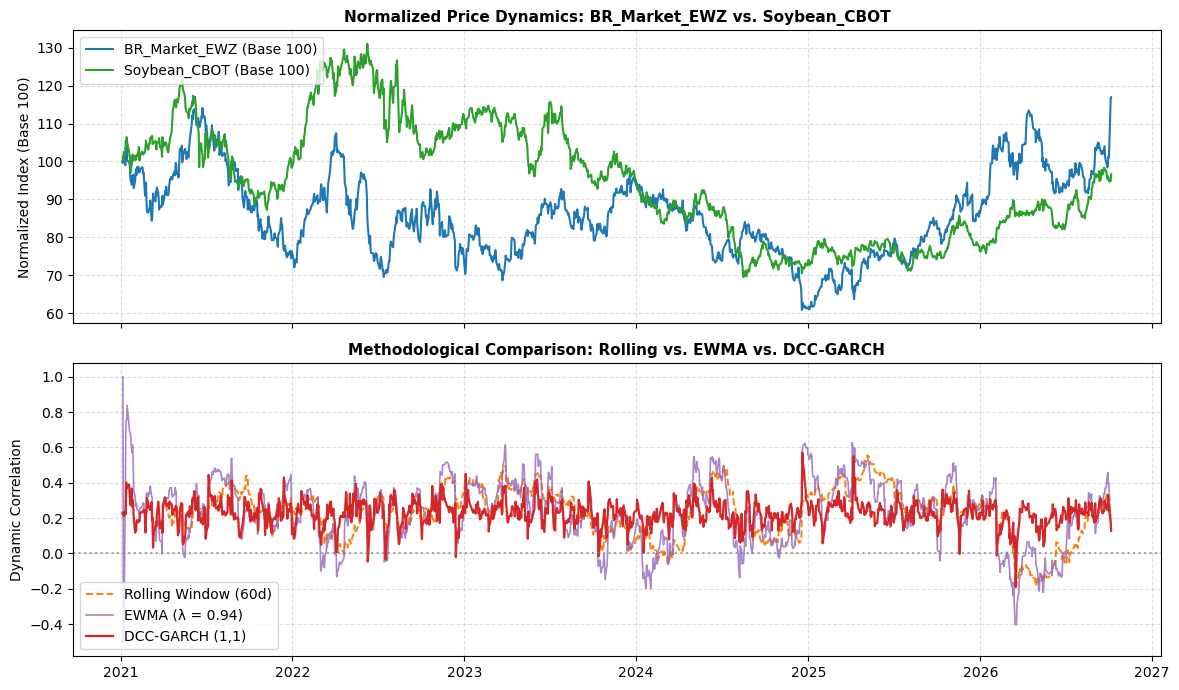

\nProcessing: Impact of global risk-free rate on agricultural cost of capital
Generating dashboard for US_10Y_Treasury_Yield vs Soybean_CBOT using models: Rolling, EWMA, DCC-GARCH...
Comparative plot successfully saved: 03_treasury10y_vs_soybean_garch.png


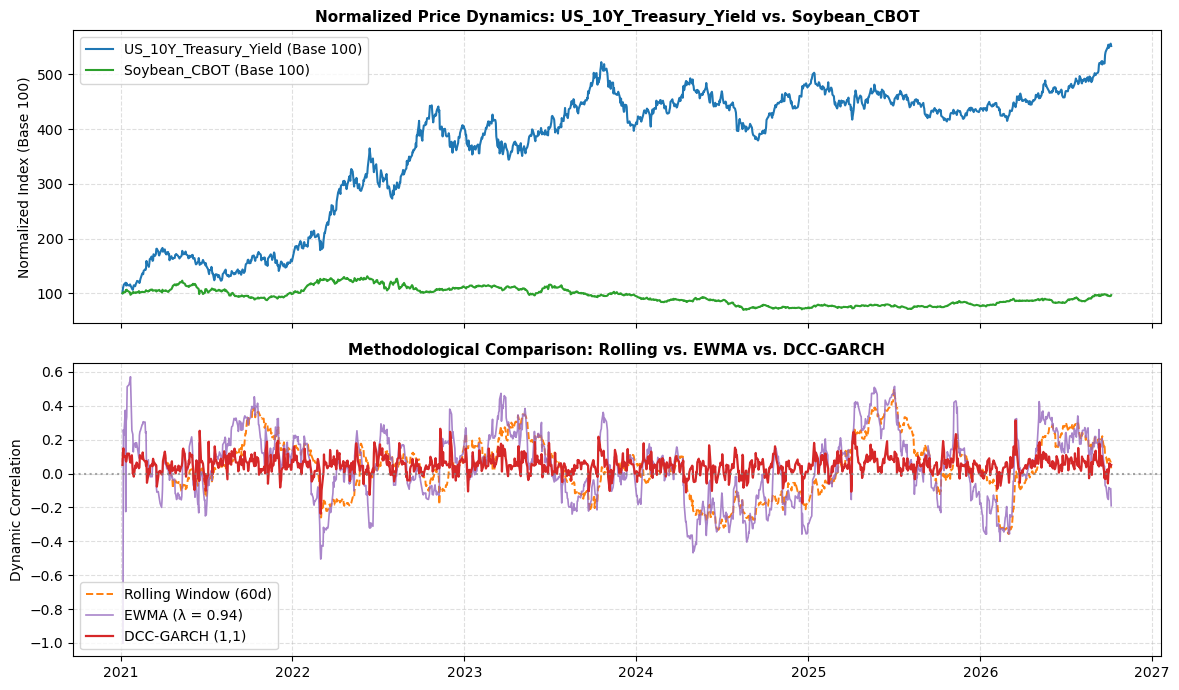

\nProcessing: Global private credit risk appetite vs. Brazilian assets
Generating dashboard for High_Yield_Bonds_HYG vs BR_Market_EWZ using models: Rolling, EWMA, DCC-GARCH...
Comparative plot successfully saved: 04_hyg_vs_ewz_garch.png


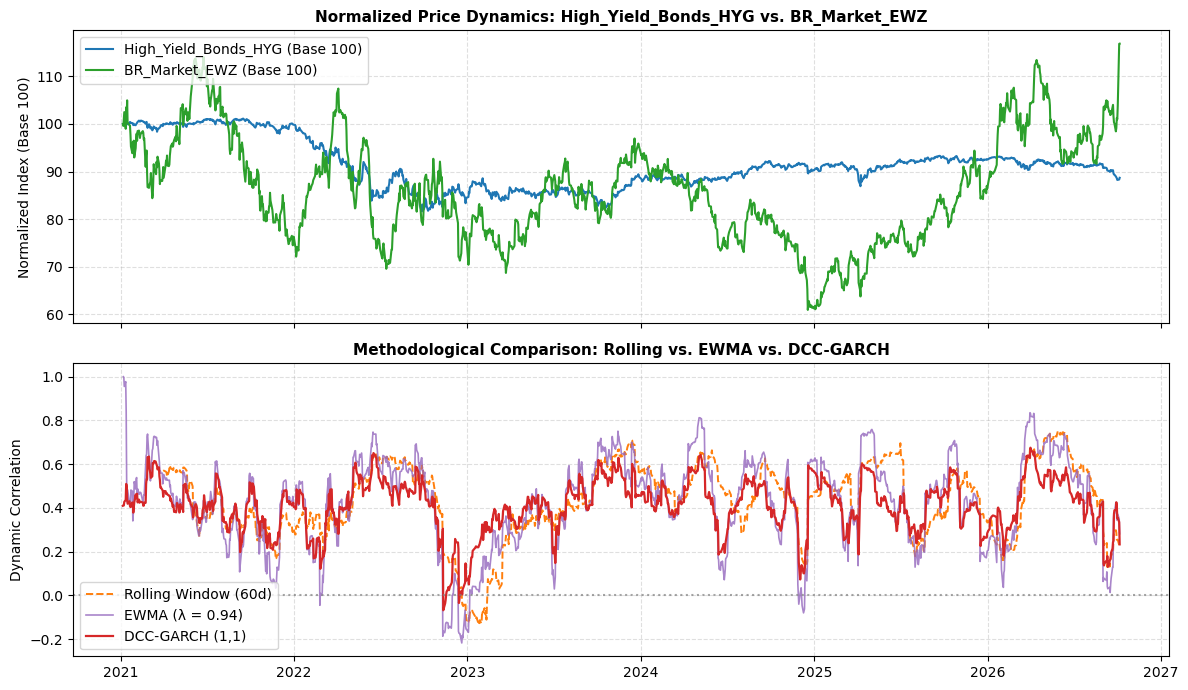

\nProcessing: Logistics/diesel costs vs. grain and biofuel revenue
Generating dashboard for Brent_Oil vs Corn_CBOT using models: Rolling, EWMA, DCC-GARCH...
Comparative plot successfully saved: 05_brent_vs_corn_garch.png


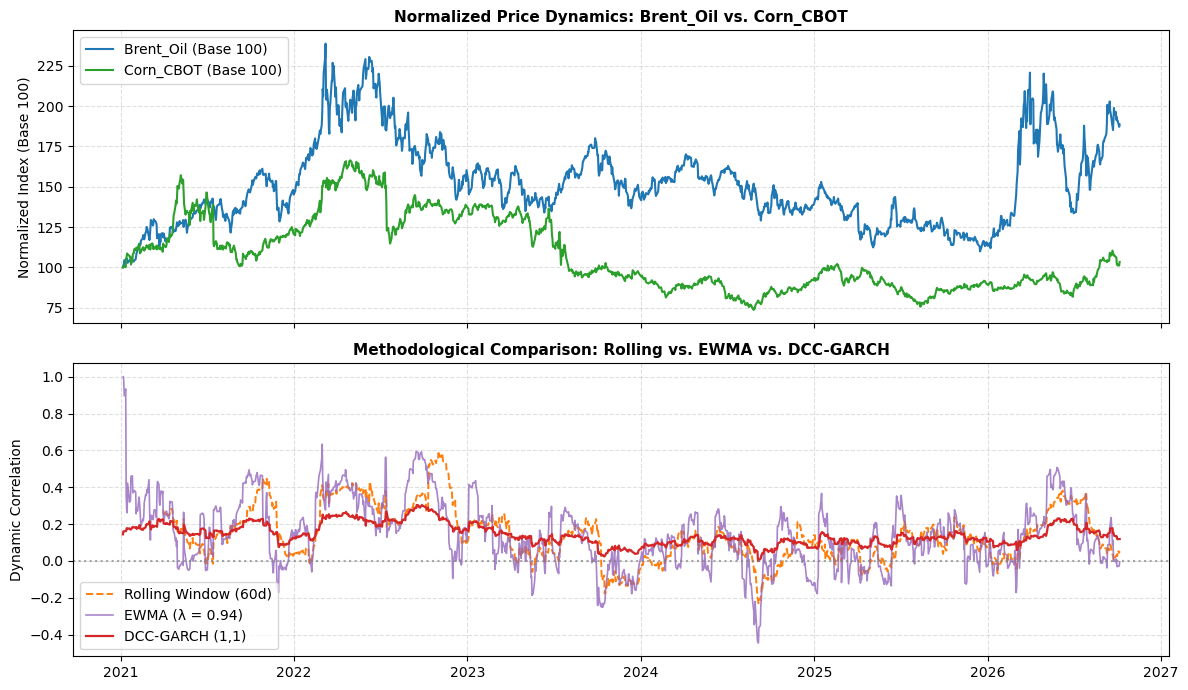

\nProcessing: Natural hedge vs. inflationary pressure from imported inputs
Generating dashboard for Dollar_BRL vs SLC_Agricola using models: Rolling, EWMA, DCC-GARCH...
Comparative plot successfully saved: 06_dollar_vs_slce3_garch.png


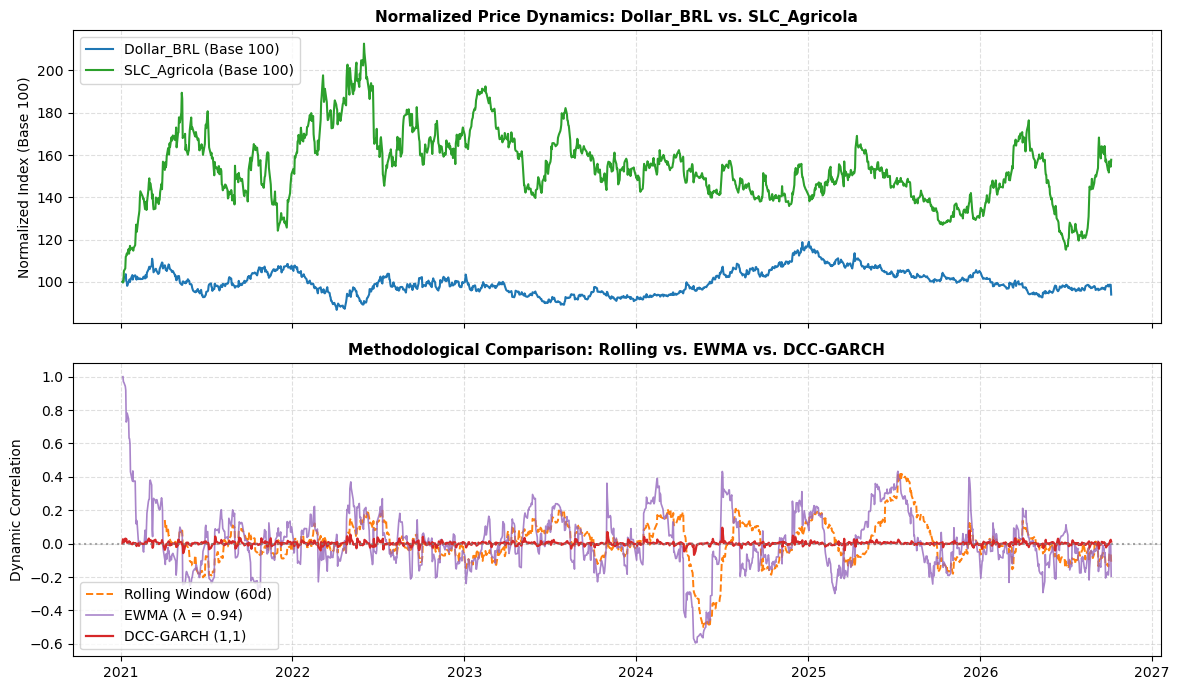

In [29]:
# ==============================================================================
# Parameterized Executions: Multi-Asset Analysis
# ==============================================================================
if __name__ == "__main__":
    
    study_pairs = [
        # --- Block 1: Classic Market Benchmark (Corporate vs. Commodity) ---
        {
            "ticker_a": "PETR4.SA", "label_a": "Petrobras_PN",
            "ticker_b": "BZ=F",     "label_b": "Brent_Oil",
            "output": "01_petr4_vs_brent_garch.png",
            "desc": "International parity pass-through vs. corporate/state risk"
        },
        
        # --- Block 2: Country Risk and Agricultural Demand (Macro vs. Agro) ---
        {
            "ticker_a": "EWZ",      "label_a": "BR_Market_EWZ",
            "ticker_b": "ZS=F",     "label_b": "Soybean_CBOT",
            "output": "02_ewz_vs_soybean_garch.png",
            "desc": "Stock market sensitivity and foreign flow to harvest yields"
        },

        # --- Block 3: Global Funding Cost and Interest Rates (Debt & Funding) ---
        {
            "ticker_a": "^TNX",     "label_a": "US_10Y_Treasury_Yield",
            "ticker_b": "ZS=F",     "label_b": "Soybean_CBOT",
            "output": "03_treasury10y_vs_soybean_garch.png",
            "desc": "Impact of global risk-free rate on agricultural cost of capital"
        },

        # --- Block 4: Corporate Credit Stress / Default (Credit Risk) ---
        {
            "ticker_a": "HYG",      "label_a": "High_Yield_Bonds_HYG",
            "ticker_b": "EWZ",      "label_b": "BR_Market_EWZ",
            "output": "04_hyg_vs_ewz_garch.png",
            "desc": "Global private credit risk appetite vs. Brazilian assets"
        },

        # --- Block 5: Input Cost vs. Selling Price (Operating Margin) ---
        {
            "ticker_a": "BZ=F",     "label_a": "Brent_Oil",
            "ticker_b": "ZC=F",     "label_b": "Corn_CBOT",
            "output": "05_brent_vs_corn_garch.png",
            "desc": "Logistics/diesel costs vs. grain and biofuel revenue"
        },

        # --- Block 6: Currency Risk in Dollarized Rural Production ---
        {
            "ticker_a": "USDBRL=X", "label_a": "Dollar_BRL",
            "ticker_b": "SLCE3.SA", "label_b": "SLC_Agricola",
            "output": "06_dollar_vs_slce3_garch.png",
            "desc": "Natural hedge vs. inflationary pressure from imported inputs"
        }
    ]
    
    # Example execution loop (uncomment to run)
    for pair in study_pairs:
        print(f"\\nProcessing: {pair['desc']}")
        prices_df, returns_df = prepare_returns_pair(
            ticker_a=pair["ticker_a"], 
            ticker_b=pair["ticker_b"], 
            label_a=pair["label_a"], 
            label_b=pair["label_b"]
        )
        plot_models_comparison(
            prices=prices_df, 
            returns=returns_df, 
            label_a=pair["label_a"], 
            label_b=pair["label_b"], 
            models_shown=["Rolling", "EWMA","DCC-GARCH"],
            output_filename=pair["output"]
         )